In [1]:
from mlx.nn import ReLU
import mlx.data as dx
import mlx.core as mx

from importlib import reload

import src.processing
reload(src.processing)

from src.config import OptimizerConfig, EncoderConfig
from src.processing import get_all_dataset, get_trades_tokenizer, get_volatility_seq, save_tokenizer, load_tokenizer, get_num_embedding_tokenizer, compute_df_feature, encode_df_feature, load_market_cap
from copy import deepcopy

from dotenv import load_dotenv
import os 
import polars as pl

load_dotenv()
info_url = os.getenv("markr_url")
#print("INFO URL->", info_url)

market_cap = load_market_cap(info_url)
FILTER = (pl.col("marketCap") < 1_000_000_000) & (pl.col("isActive"))
selected_isins = market_cap.filter(FILTER).select("isin")
print(f"Total isins select {len(selected_isins)}/{len(market_cap)}")

CATEGORIAL_COLUMNS = ["TradeType", "MifidInstrumentID", "MmtMarketMechanism", "MmtTradingMode", "MmtAlgorithmicIndicator", "Venue"]
CONTINUOUS_COLUMNS = ["delta_event_ts", "time_cos", "time_sin", "norm_volume"]
SEQUENCE_SIZE = 20
VOLATILITY_SCALE = 1.
SAVE_DIR = "weight"
ENCODER_DEPTH = 4
EMBEDDING_DIM = [4, 8, 4, 4, 4, 4] # 8 for InstrumentID to get better clustering

dataset = get_all_dataset(dir="equities_trade")
dataset = dataset.filter(pl.col("MifidInstrumentID").is_in(selected_isins["isin"].implode()))

print(f"👾 Load {len(dataset)} trades")
print(dataset.tail(1))

tokenizer = load_tokenizer(path="tokenizer.json") 

raw_data = deepcopy(dataset) # we need it for next ceil
dataset = encode_df_feature(dataset, tokenizer)
dataset = compute_df_feature(dataset, norm_log_return_window=10, norm_volume_window=10)


encoder_config = EncoderConfig(num_continuous_col=len(CONTINUOUS_COLUMNS), 
                              depth=ENCODER_DEPTH,
                              embedding_dim=EMBEDDING_DIM,
                              num_embedding=get_num_embedding_tokenizer(tokenizer, CATEGORIAL_COLUMNS),
                              categorical_col=CATEGORIAL_COLUMNS)

print("[TEST] ", get_num_embedding_tokenizer(tokenizer, CATEGORIAL_COLUMNS))
dataset


Total isins select 624/1039
Found 6 files in directory
👾 Load 742890 trades
shape: (1, 12)
┌────────────┬────────────┬────────────┬───────────┬───┬───────────┬───────────┬───────────┬───────┐
│ EventTime  ┆ TradingDat ┆ Publicatio ┆ MifidInst ┆ … ┆ MmtMarket ┆ MmtTradin ┆ MmtAlgori ┆ Venue │
│ ---        ┆ eTime      ┆ nDateTime  ┆ rumentID  ┆   ┆ Mechanism ┆ gMode     ┆ thmicIndi ┆ ---   │
│ str        ┆ ---        ┆ ---        ┆ ---       ┆   ┆ ---       ┆ ---       ┆ cator     ┆ str   │
│            ┆ str        ┆ str        ┆ str       ┆   ┆ str       ┆ str       ┆ ---       ┆       │
│            ┆            ┆            ┆           ┆   ┆           ┆           ┆ str       ┆       │
╞════════════╪════════════╪════════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════╡
│ 2026-03-12 ┆ 2026-03-12 ┆ 2026-03-12 ┆ FR001400A ┆ … ┆ 4         ┆ 5         ┆ human     ┆ XPAR  │
│ T16:55:52. ┆ T16:55:23. ┆ T16:55:53. ┆ HX6       ┆   ┆           ┆           ┆           ┆       │


MifidInstrumentID,delta_ts,log_return,log_volume,norm_log_return,norm_volume,TradeType,MmtMarketMechanism,MmtTradingMode,MmtAlgorithmicIndicator,Venue,event_ts,time_cos,time_sin,MifidPrice
i32,list[f64],list[f64],list[f64],list[f64],list[f64],list[i32],list[i32],list[i32],list[i32],list[i32],list[i64],list[f64],list[f64],list[f64]
399,"[0.0, 0.0, … 0.0]","[0.0, 0.0, … 0.0]","[2.197225, 2.079442, … 0.693147]","[0.0, 0.0, … 0.0]","[-0.245294, -0.46116, … -2.280968]","[4, 4, … 4]","[0, 0, … 0]","[4, 4, … 0]","[0, 0, … 0]","[1, 1, … 1]","[1773043226157680, 1773043226157680, … 1774024503783857]","[1.0, 1.0, … 0.910376]","[0.0, 0.0, … 0.413782]","[44.0, 44.0, … 40.4]"
432,[],[],[],[],[],[],[],[],[],[],[],[],[],[]
533,"[0.0, 0.000003, … 2.0461e-10]","[0.082238, -0.096627, … 0.0]","[10.109648, 0.693147, … 4.812184]","[0.095756, -0.135023, … -0.011568]","[2.893683, -5.630545, … -1.340875]","[4, 4, … 4]","[0, 0, … 0]","[1, 1, … 0]","[0, 0, … 0]","[1, 1, … 1]","[1773143131709515, 1773147977355316, … 1774024505310009]","[-0.097488, -0.887833, … 0.908539]","[0.995237, 0.460166, … 0.4178]","[0.038, 0.0345, … 0.0595]"
39,"[8.1150e-7, 1.7390e-8, … 1.1761e-7]","[0.0, -0.020479, … 0.003407]","[5.525453, 3.583519, … 4.836282]","[-0.000678, -0.019109, … 0.003066]","[1.327022, -0.81232, … 3.461406]","[7, 4, … 4]","[0, 0, … 0]","[1, 1, … 1]","[0, 1, … 0]","[2, 2, … 2]","[1773051482414952, 1773051513248273, … 1774024049857301]","[-0.126049, -0.132327, … 0.944312]","[0.992024, 0.991206, … 0.329052]","[2.96, 2.9, … 2.94]"
21,"[0.0, 0.0, … 0.0]","[0.0, 0.0, … 0.0]","[1.94591, 0.693147, … 1.098612]","[0.004779, 0.004779, … 0.000702]","[0.69956, -0.553203, … -0.418728]","[4, 4, … 4]","[0, 0, … 0]","[0, 0, … 0]","[1, 0, … 0]","[2, 2, … 2]","[1773675004714719, 1773675004714719, … 1774020602202590]","[-0.60077, -0.60077, … -0.604907]","[0.799422, 0.799422, … -0.796296]","[286.0, 286.0, … 284.0]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
119,"[0.000002, 0.0, … 8.8531e-7]","[0.050107, 0.029632, … -0.03101]","[7.378384, 9.036106, … 6.908755]","[0.05307, 0.022052, … -0.027528]","[-0.263547, 1.093633, … 0.482606]","[4, 7, … 4]","[0, 0, … 0]","[1, 1, … 1]","[0, 0, … 1]","[2, 2, … 2]","[1773134432259477, 1773134432259477, … 1774014280617928]","[-0.291819, -0.291819, … -0.962172]","[-0.956474, -0.956474, … 0.272444]","[0.0532, 0.0548, … 0.0508]"
375,"[0.0, 0.0, … 0.0]","[0.0, 0.0, … 0.0]","[5.70711, 1.609438, … 0.693147]","[0.0, 0.0, … 0.0]","[1.928104, -2.220651, … -5.246541]","[4, 4, … 4]","[0, 0, … 0]","[4, 4, … 0]","[1, 1, … 1]","[2, 2, … 2]","[1773043212300789, 1773043212300789, … 1774024520490104]","[1.0, 1.0, … 0.907689]","[0.000173, 0.000173, … 0.419644]","[0.382, 0.382, … 0.385]"
500,"[0.000041, 0.0]","[0.0, 0.0]","[4.624973, 4.624973]","[0.00113, 0.00113]","[1.831839, 1.609132]","[4, 4]","[0, 0]","[3, 3]","[1, 1]","[1, 1]","[1773920207803982, 1773920207803982]","[-0.994374, -0.994374]","[0.105926, 0.105926]","[8.8, 8.8]"


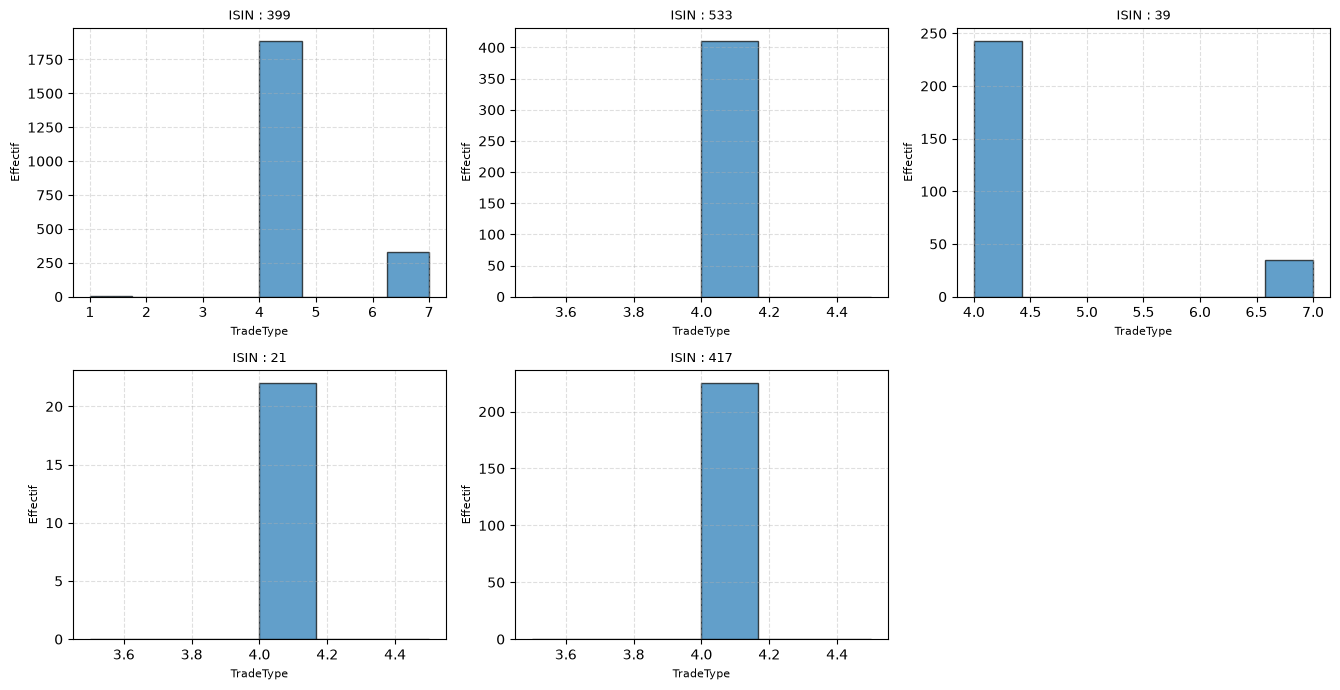

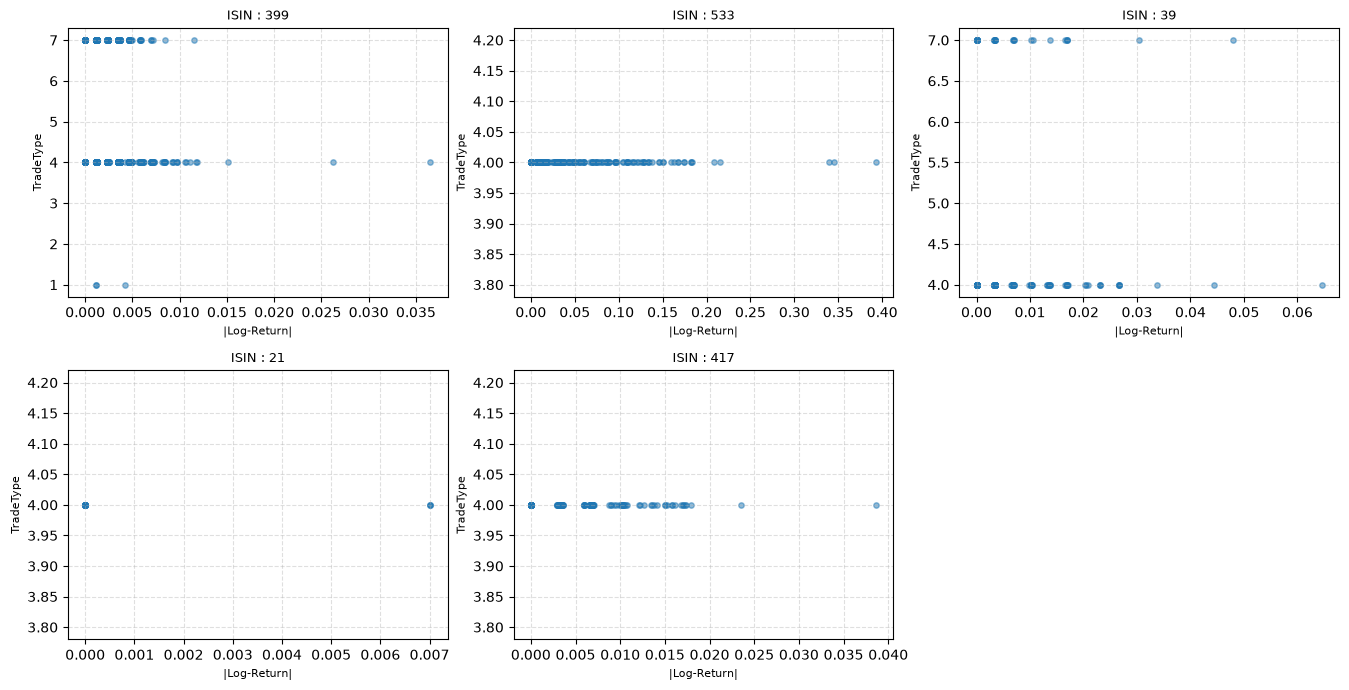

<Figure size 1350x700 with 0 Axes>

<Figure size 1350x700 with 0 Axes>

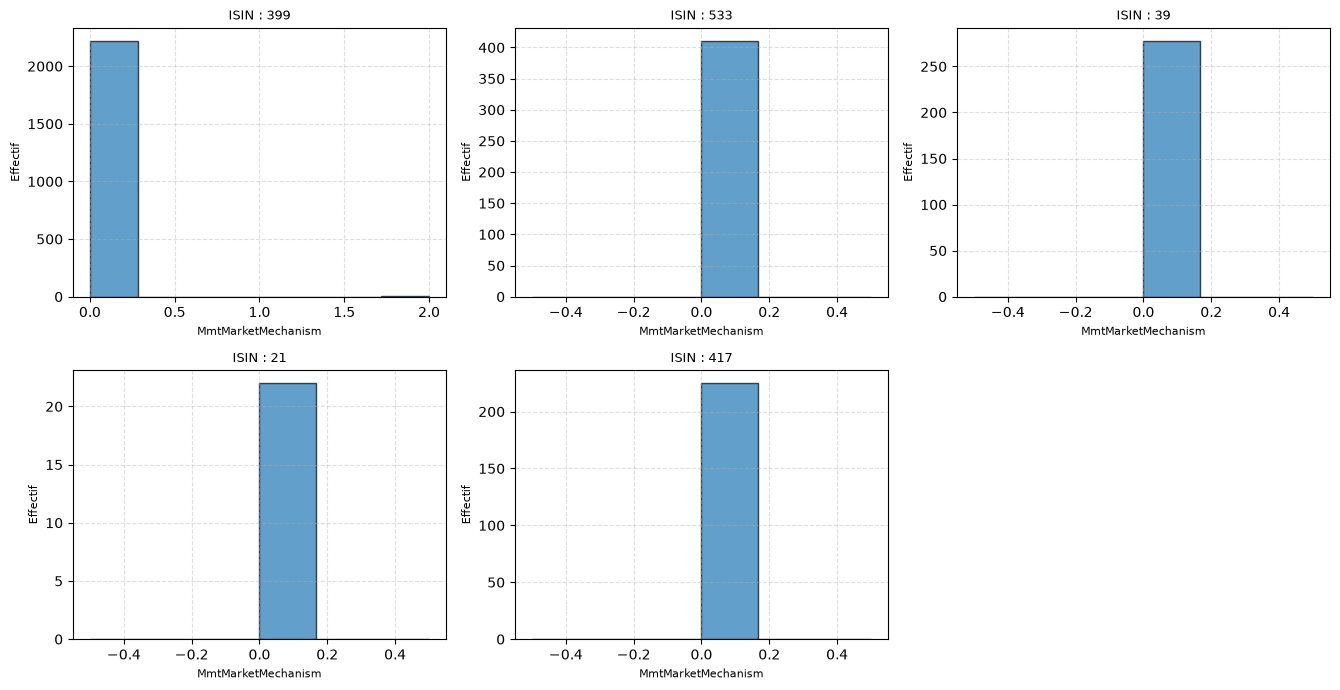

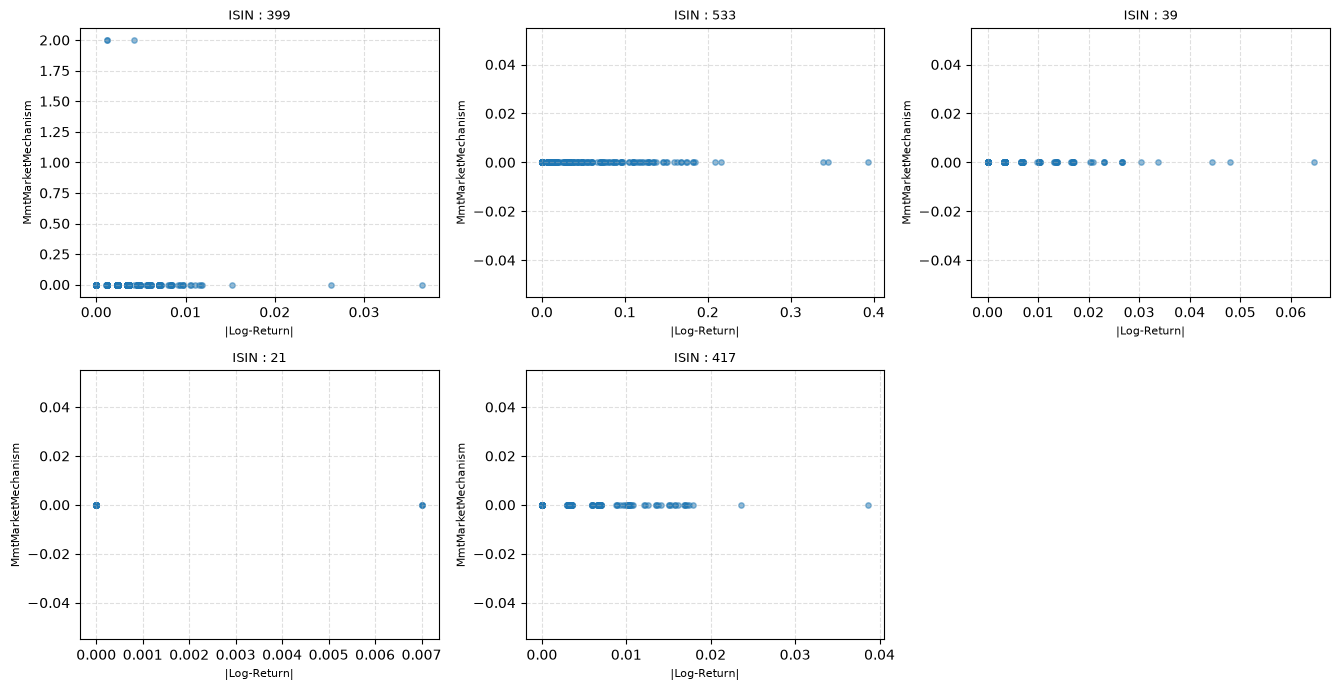

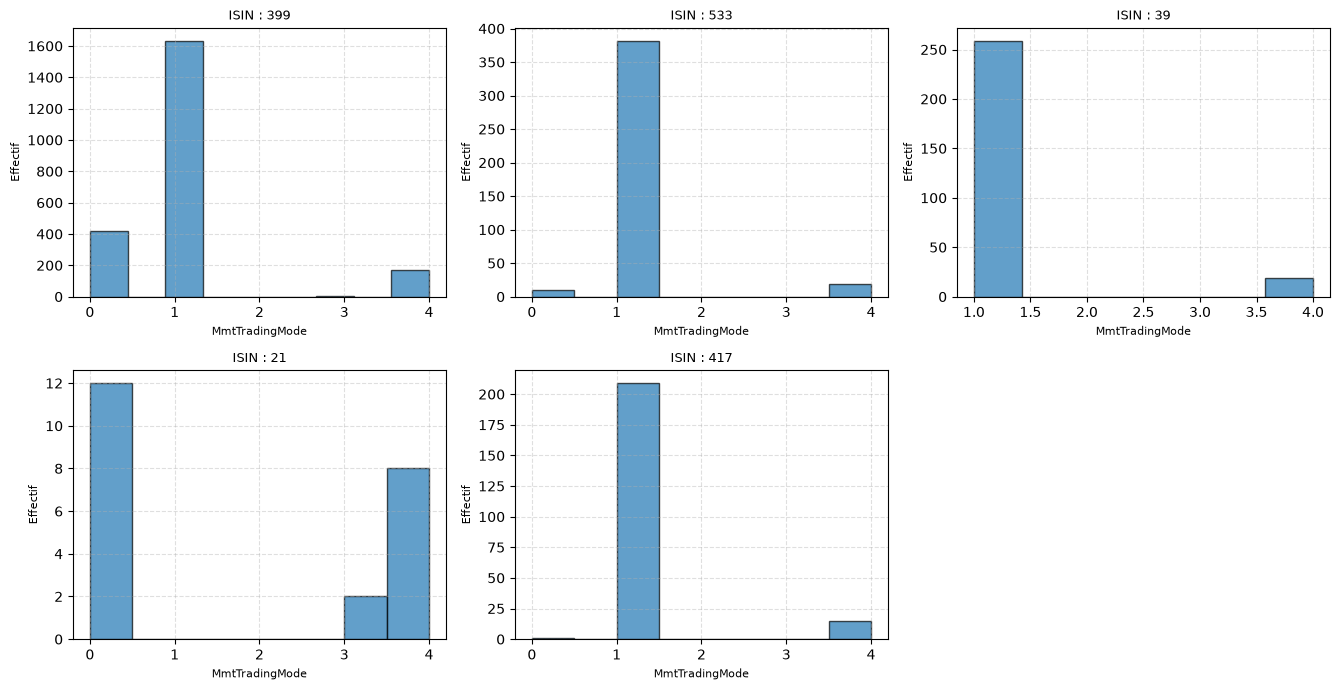

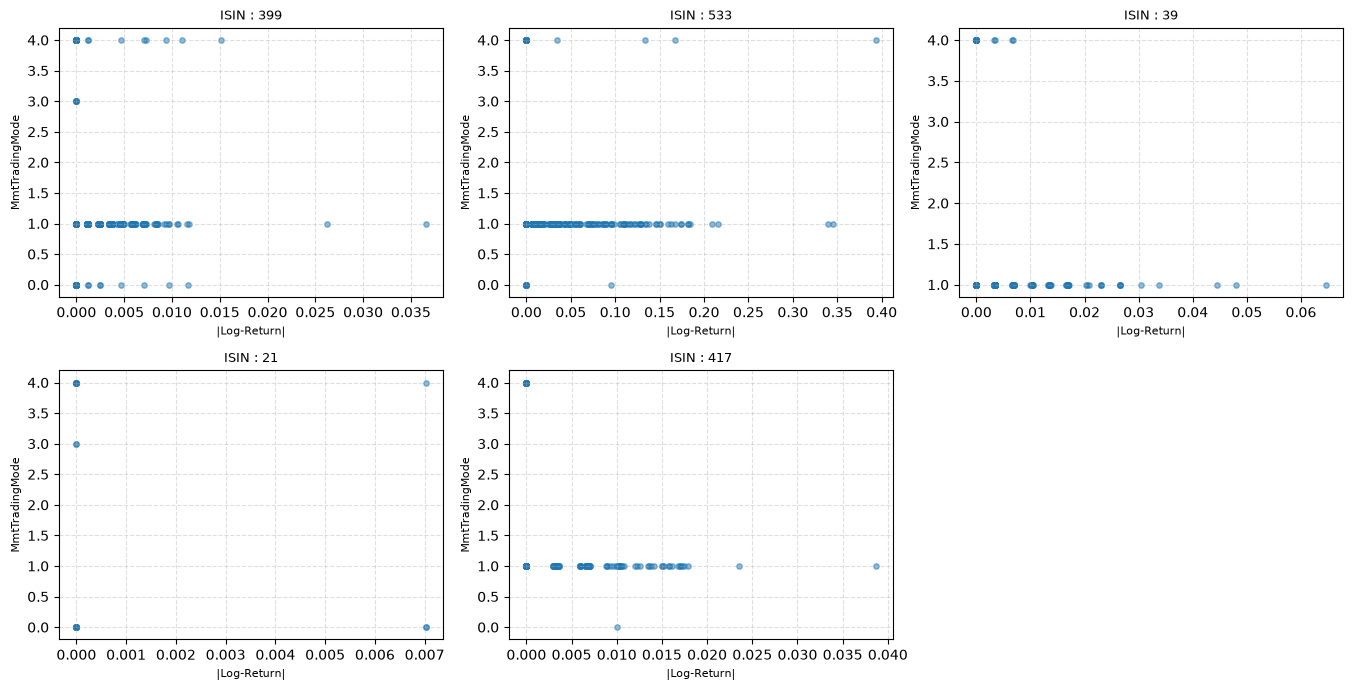

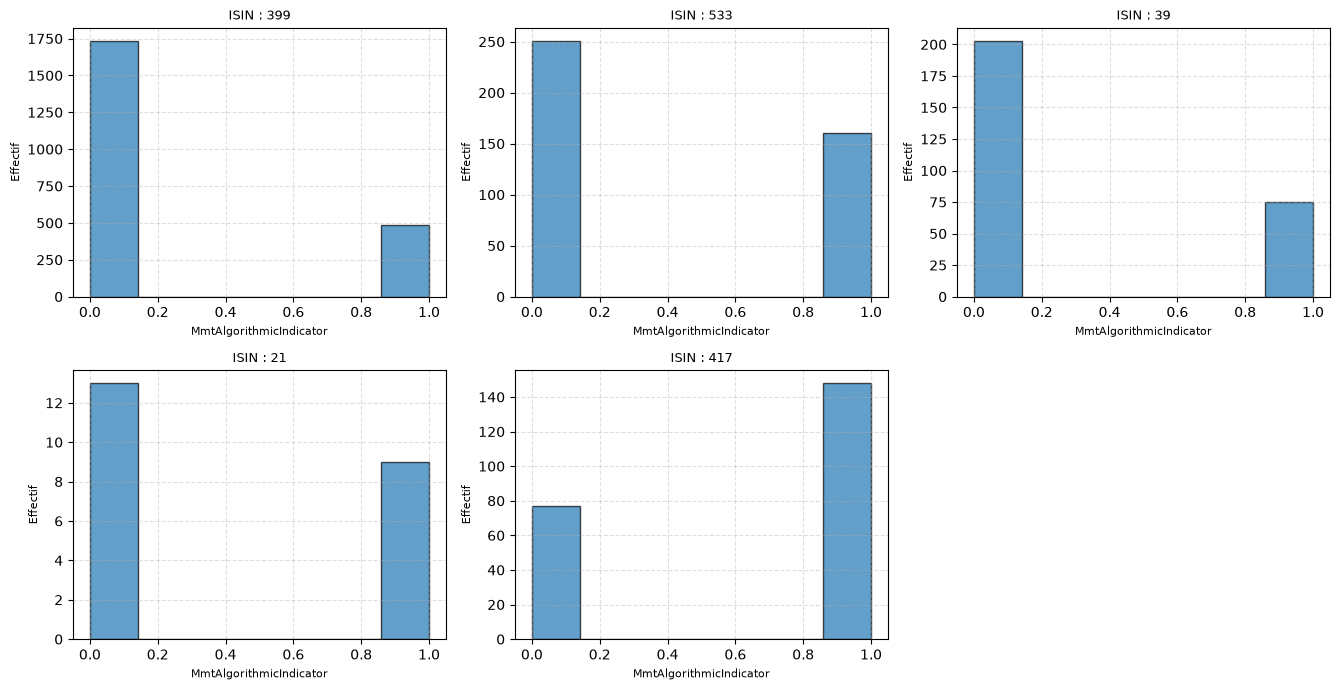

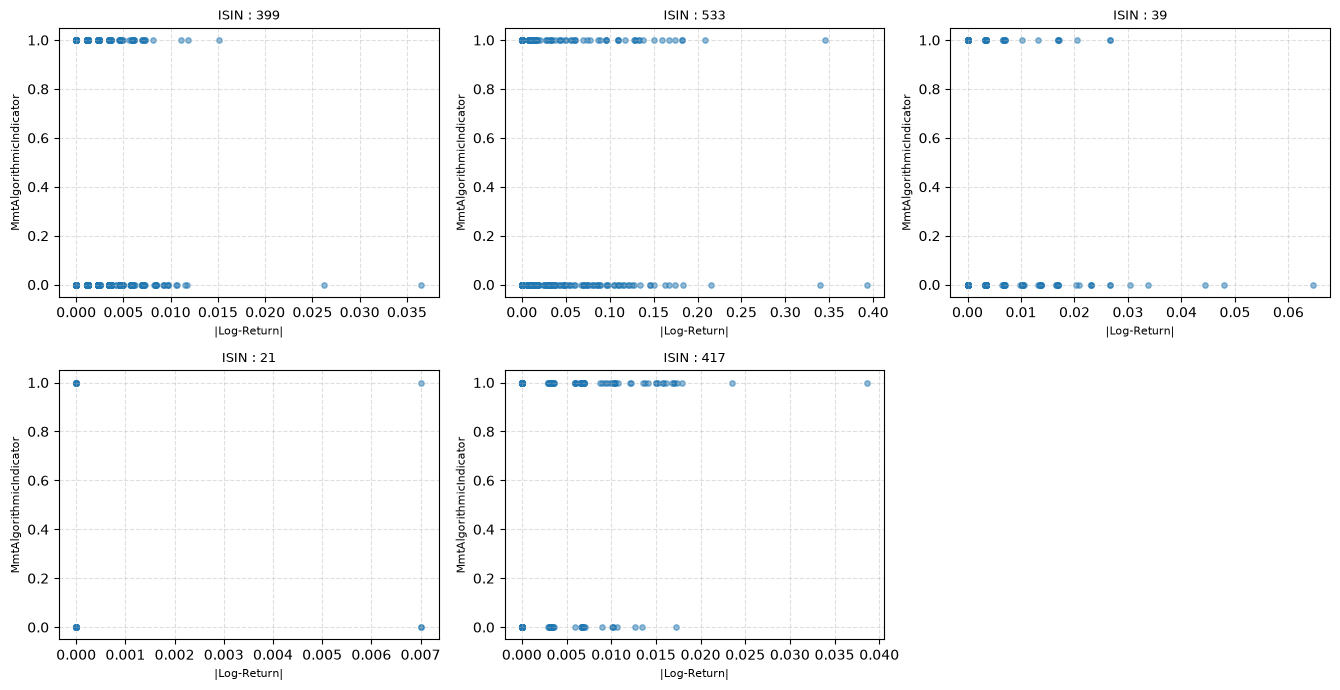

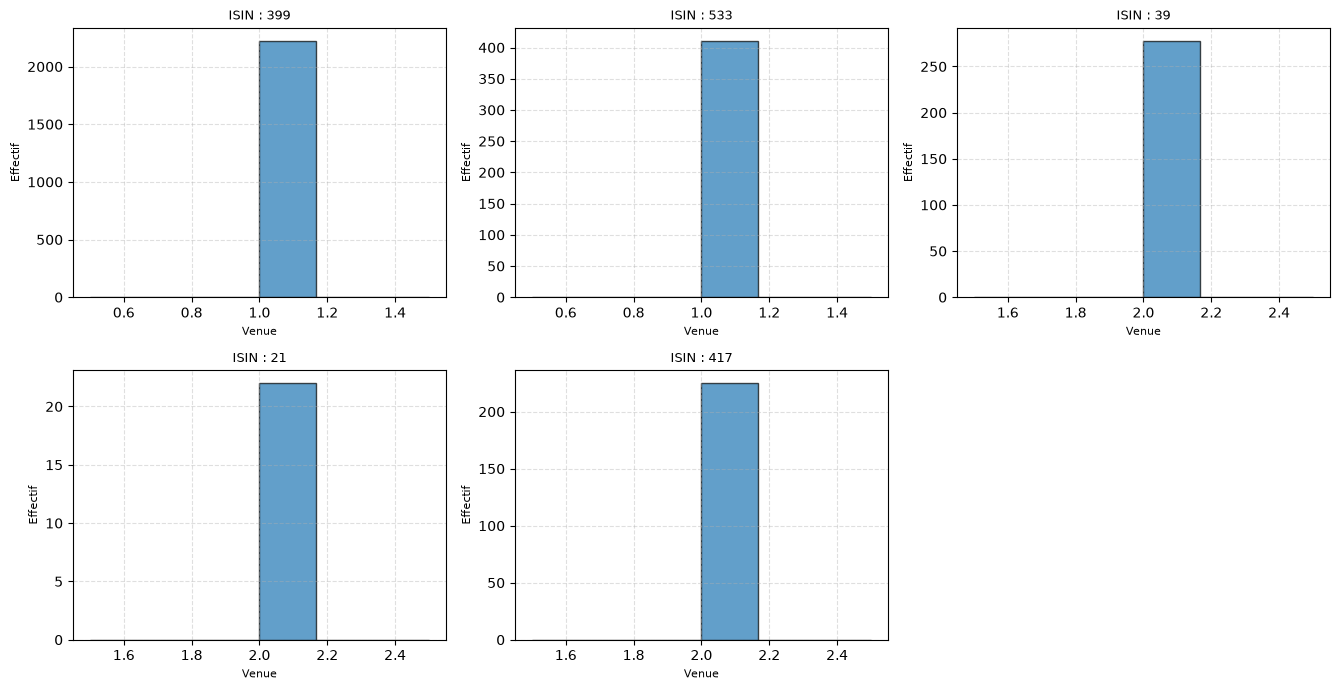

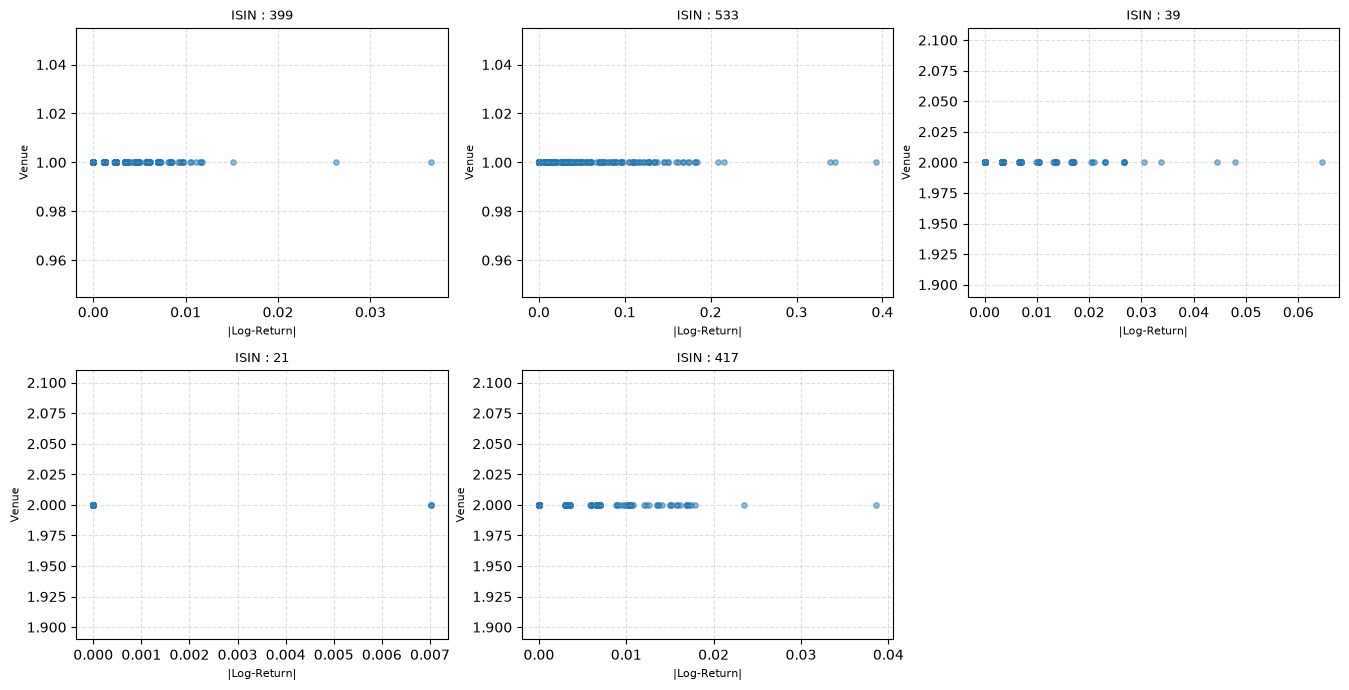

In [ ]:
import math
import matplotlib.pyplot as plt
import numpy as np
import polars as pl


def inspect_class_repartition(
    df: pl.DataFrame,
    n_sample: int = 6,
    min_samples: int = 20,
    col: str = "TradeType",
    n_cols: int = 3,
):
    n_rows = math.ceil(n_sample / n_cols)
    fig, axes = plt.subplots(
        nrows=n_rows,
        ncols=n_cols,
        figsize=(n_cols * 4.5, n_rows * 3.5),
        squeeze=False,
    )
    axes_flat = axes.flatten()

    i = 0
    for row in df.iter_rows(named=True):
        if i == n_sample:
            break
        feat = np.array(row[col]).flatten()
        isin = row["MifidInstrumentID"]

        if len(feat) < min_samples:
            continue

        n_bins = len(np.unique(feat)) + 5
        axes_flat[i].hist(feat, bins=n_bins, edgecolor="black", alpha=0.7)
        axes_flat[i].set_title(f"ISIN : {isin}", fontsize=9)
        axes_flat[i].set_xlabel(col, fontsize=8)
        axes_flat[i].set_ylabel("Effectif", fontsize=8)
        axes_flat[i].grid(True, linestyle="--", alpha=0.4)
        i += 1

    for j in range(i, len(axes_flat)):
        fig.delaxes(axes_flat[j])

    fig.tight_layout()
    plt.show()
    return fig


def plot_col_against_return(
    df: pl.DataFrame,
    n_sample: int = 6,
    min_samples: int = 20,
    col: str = "TradeType",
    n_cols: int = 3,
):
    n_rows = math.ceil(n_sample / n_cols)
    fig, axes = plt.subplots(
        nrows=n_rows,
        ncols=n_cols,
        figsize=(n_cols * 4.5, n_rows * 3.5),
        squeeze=False,
    )
    axes_flat = axes.flatten()

    i = 0
    for row in df.iter_rows(named=True):
        if i == n_sample:
            break
        feat_x = np.abs(np.array(row["log_return"]).flatten())
        feat_y = np.array(row[col]).flatten()
        isin = row["MifidInstrumentID"]

        if len(feat_x) < min_samples or len(feat_x) != len(feat_y):
            continue

        axes_flat[i].scatter(feat_x, feat_y, alpha=0.5, s=15)
        axes_flat[i].set_title(f"ISIN : {isin}", fontsize=9)
        axes_flat[i].set_xlabel("|Log-Return|", fontsize=8)
        axes_flat[i].set_ylabel(col, fontsize=8)
        axes_flat[i].grid(True, linestyle="--", alpha=0.4)
        i += 1

    for j in range(i, len(axes_flat)):
        fig.delaxes(axes_flat[j])

    fig.tight_layout()
    plt.show()
    return fig

os.makedirs("plot/dataset_analyse", exist_ok=True)

for col in CATEGORIAL_COLUMNS:
    if col == "MifidInstrumentID":
        continue
    fig1=inspect_class_repartition(dataset, n_sample=5, col=col)
    fig2=plot_col_against_return(dataset, n_sample=5, col=col)

    path = f"plot/dataset_analyse/{col}"
    fig1.savefig(path+"_repartition.png")
    fig2.savefig(path+"_against_absolute_return.png")


In [ ]:
from src.processing import get_dataset_volatility, get_num_embedding
import polars as pl

# In this section we'll use Trainer2 to train the model to reconstruct only the trade in the middle of the window 
# In next section we'll explore the classic trainer and see if results differ

CATEGORICAL_COLUMNS = ["MifidInstrumentID", "TradeType", "MmtMarketMechanism", "MmtTradingMode", "MmtAlgorithmicIndicator", "Venue"] 
CONTINUOUS_COLUMNS = ["delta_ts", "time_cos", "time_sin", "norm_volume"] 
EMBEDDING_DIM= np.full(len(CATEGORICAL_COLUMNS), fill_value=4)
EMBEDDING_DIM[0]=8 # more embedding on instrument id for better clustering
print(EMBEDDING_DIM)
HIDDEN_SIZE = 32    

import time
from src.config import VAEConfig
from src.vae import VAE
import src.trainer
reload(src.trainer)
from src.trainer import VAETrainer, VAETrainer2
from src.processing import get_vae_seq

vae_no_agno_config = VAEConfig(
    compression_ratio=2.0,
    hidden_size=HIDDEN_SIZE,
    activation=ReLU,
    dropout_rate=0.2
)


encoder_no_agno_config = EncoderConfig(num_continuous_col=len(CONTINUOUS_COLUMNS), 
                              depth=ENCODER_DEPTH,
                              embedding_dim=EMBEDDING_DIM,
                              num_embedding=get_num_embedding(dataset, CATEGORICAL_COLUMNS),
                              categorical_col=CATEGORICAL_COLUMNS)


optim_vae_config = OptimizerConfig(
    optimizer_name="adamw", 
    lr = 1e-4
)

vae_model = VAE(encoder_config=encoder_no_agno_config, vae_config=vae_no_agno_config)
mx.eval(vae_model.parameters())

vae_sequence = get_vae_seq(data=dataset, categorical_col=CATEGORICAL_COLUMNS, continous_col=CONTINUOUS_COLUMNS, sq_size=SEQUENCE_SIZE)
start = time.time()
vae_buffer = dx.buffer_from_vector(vae_sequence)
print('MLX buffer init in ', time.time() - start, "second")

vae_trainer = VAETrainer2(model=vae_model, 
                         optim_config=optim_vae_config, 
                         buffer=vae_buffer, 
                         categorical_columns=CATEGORICAL_COLUMNS,
                         train_size=0.7, 
                         batch_size=1024) 

vae_trainer.epoch(n_epoch=12,
                  save_dir= SAVE_DIR,
                  model_name=f"vae_{HIDDEN_SIZE}",
                  plot_chart=True)


[8 4 4 4 4 4]


100%|██████████| 425/425 [00:02<00:00, 207.36it/s]


MLX buffer init in  0.9160327911376953 second
MLX train buffer init in  1.4772307872772217
MLX test buffer init in  0.5619411468505859
EPOCH 1 --- 


501it [01:56,  4.29it/s]
215it [00:08, 26.06it/s]


TRAIN LOSS 571090.1759825076 ||| TEST LOSS 9038.628121593387
EPOCH 2 --- 


...

501it [01:53,  4.42it/s]
215it [00:07, 28.79it/s]


TRAIN LOSS 649098.6310255466 ||| TEST LOSS 4469.248956440771
EPOCH 4 --- 


501it [01:19,  6.33it/s]
215it [00:03, 58.92it/s]


TRAIN LOSS 390483.4017984539 ||| TEST LOSS 3099.821804028888
EPOCH 5 --- 


425it [00:55,  7.65it/s]

====== Volatility Model ===== (Task B)

In [ ]:
from src.trainer import VolatilityTrainer
from src.volatility_nn import VolatilityEstimator
from src.config import VolatilityConfig

HIDDEN_SIZE = 32

volatility_config = VolatilityConfig(
    hidden_size=HIDDEN_SIZE, 
    activation=ReLU,
    dropout_rate=0.2
)

optimizer_config = OptimizerConfig(optimizer_name="adam", lr=1e-4)
volatility_model = VolatilityEstimator(encoder_config=encoder_config, volatility_config=volatility_config)
mx.eval(volatility_model.parameters())


sequence_data = get_volatility_seq(dataset, categorical_col=CATEGORIAL_COLUMNS, continous_col=CONTINUOUS_COLUMNS, sq_size=SEQUENCE_SIZE)
buffer = dx.buffer_from_vector(sequence_data)
print(f"MLX Buffer size --> {len(buffer)}")

trainer = VolatilityTrainer(model=volatility_model, 
                            optim_config=optimizer_config, 
                            buffer=buffer, 
                            categorical_columns=CATEGORIAL_COLUMNS, 
                            train_size=0.7,
                            batch_size=1024,
                            scale= VOLATILITY_SCALE)

trainer.epoch(n_epoch=10, 
              save_dir=SAVE_DIR, 
              model_name=f"volatility_model_{HIDDEN_SIZE}", 
              plot_chart=True)



100%|██████████| 598/598 [01:13<00:00,  8.16it/s]


Target mean -->  0.9091292 +/- 2.4164073
references quantile --> [0.25, 0.5, 0.75, 0.9]
Target quantile --> [0.38796467 0.55826437 0.85665661 1.62671494]
MLX Buffer size --> 6362775
MLX train buffer init in  33.034027099609375
MLX test buffer init in  23.837219715118408
EPOCH 1 --- 


4350it [2:02:56,  1.70s/it]
1865it [10:57,  2.84it/s]


TRAIN LOSS 2.151548365916329 ||| TEST LOSS 1.4327683098194746
EPOCH 2 --- 


4350it [1:47:48,  1.49s/it]
1865it [11:55,  2.61it/s]


...

TRAIN LOSS 2.1465963696337296 ||| TEST LOSS 1.4183056363471391
EPOCH 7 --- 


4350it [2:07:45,  1.76s/it]
1865it [23:47,  1.31it/s]


TRAIN LOSS 2.146361902828874 ||| TEST LOSS 1.4215144534852486
EPOCH 8 --- 


179it [06:22,  2.14s/it]


KeyboardInterrupt: 

======= Variational version ===========

100%|██████████| 598/598 [01:09<00:00,  8.58it/s]


Target mean -->  0.9091292 +/- 2.4164064
references quantile --> [0.25, 0.5, 0.75, 0.9]
Target quantile --> [0.38796467 0.55826437 0.85665661 1.62671494]
MLX Buffer size --> 6362775
MLX train buffer init in  28.782665967941284
MLX test buffer init in  17.199116945266724
EPOCH 1 --- 


4350it [37:26,  1.94it/s]
1865it [05:53,  5.28it/s]


TRAIN LOSS nan ||| TEST LOSS nan
EPOCH 2 --- 


4350it [39:47,  1.82it/s]
1865it [06:41,  4.65it/s]


...

TRAIN LOSS nan ||| TEST LOSS nan
EPOCH 9 --- 


4350it [41:42,  1.74it/s]
1865it [07:28,  4.16it/s]


TRAIN LOSS nan ||| TEST LOSS nan
EPOCH 10 --- 


4350it [46:29,  1.56it/s]
1865it [08:53,  3.50it/s]


TRAIN LOSS nan ||| TEST LOSS nan


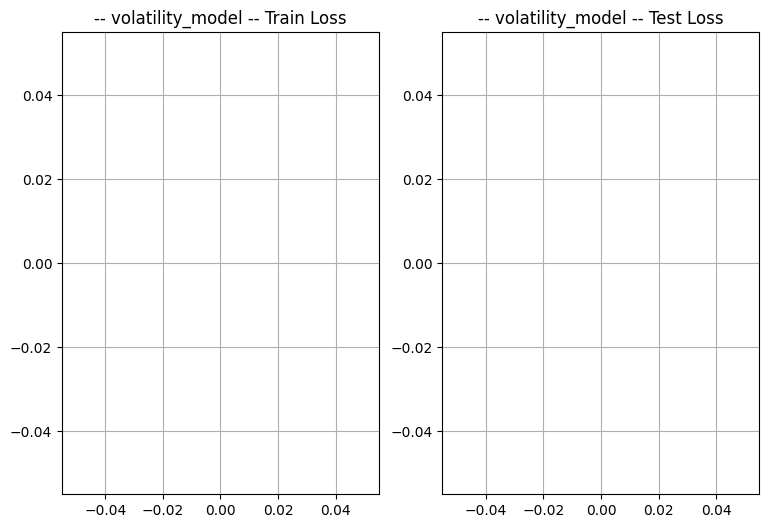

In [2]:

from src.trainer import VolatilityTrainer
from src.volatility_nn import VariationalVolatilityEstimator
from src.config import VolatilityConfig

volatility_config = VolatilityConfig(
    hidden_size=32, 
    activation=ReLU,
    dropout_rate=0.2
)

optimizer_config = OptimizerConfig(optimizer_name="adam", lr=1e-4)
volatility_model = VariationalVolatilityEstimator(encoder_config=encoder_config, volatility_config=volatility_config)
mx.eval(volatility_model.parameters())


sequence_data = get_volatility_seq(dataset, categorical_col=CATEGORIAL_COLUMNS, continous_col=CONTINUOUS_COLUMNS, sq_size=SEQUENCE_SIZE)
buffer = dx.buffer_from_vector(sequence_data)
print(f"MLX Buffer size --> {len(buffer)}")

trainer = VolatilityTrainer(model=volatility_model, 
                            optim_config=optimizer_config, 
                            buffer=buffer, 
                            categorical_columns=CATEGORIAL_COLUMNS, 
                            train_size=0.7,
                            batch_size=1024,
                            scale= VOLATILITY_SCALE)

trainer.epoch(n_epoch=10, 
              save_dir=SAVE_DIR, 
              model_name="volatility_model", 
              plot_chart=True)



** The Variational result is full of nan, this model is unstable with this state of parameters :     hidden_size=32, 
    activation=ReLU,
    dropout_rate=0.2